In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
orders = pd.read_excel("../data/orders.xlsx")
products = pd.read_excel("../data/products.xlsx")
sales = orders.merge(products, on="product_id")

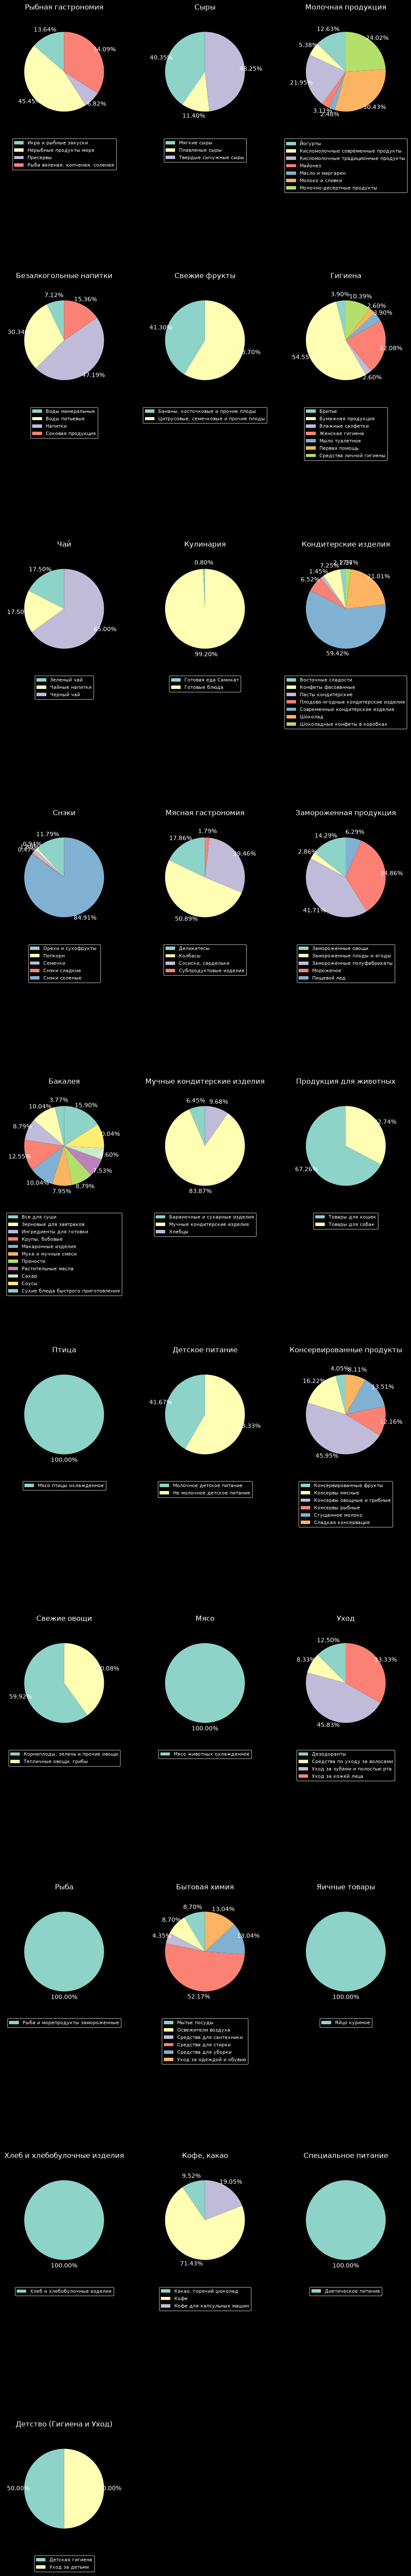

In [28]:
categories = sales['level1'].unique()
cat_count = len(categories)
rows_count = int(np.ceil(cat_count / 3))

fig, axes = plt.subplots(rows_count, 3, figsize=(12, rows_count*8))

for level1, ax in zip(categories, axes.ravel()):
    category = sales[sales['level1'] == level1]
    products = (category
                .groupby('level2')['quantity']
                .sum()
                .to_frame('quantity')
                )
    products['share'] = products['quantity'] / products['quantity'].sum()
    pie = ax.pie(
        products['share'],
        autopct = lambda pct: f"{pct:.2f}%",
        pctdistance=1.15,
        startangle=90,
        radius=0.85
    )

    ax.set_title(level1)
    ax.legend(
        pie.wedges,
        products.index,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.05),
        fontsize=8
    )

for ax in axes.ravel()[cat_count:]:
    ax.remove()

plt.show()